# Lab: Multi-Class Classification

*In this lab, we will build a multi-class classification model using scikit-learn, guided by the [Foundational Methodology for Data Science](../../../05_methodology/). While real-world projects require comprehensive documentation at each stage, this lab focuses on a streamlined, practical approach to demonstrate the core concepts and workflow. Therefore we will settle with the summaries of hypothetical stage reports.*

---

> ### 📝 1. Business Understanding Report (Summary)
> * **Business Context:** A botanical research institute has discovered that the *Iris-virginica* species possesses unique genetic properties that are valuable for developing new floral hybrids. The institute needs to collect pure samples of this species for their research.
> * **Business Problem:** The current process of identifying *Iris-virginica* relies on manual inspection, which is slow and costly. While [an initial proposal](../02_linear_and_logistic_regression/10_logistic_regression_lab.ipynb) was to build a simple binary classifier ("Is it Virginica?"), it has been determined that this is insufficient. A misclassification of another species (e.g., *Iris-setosa*) as *Iris-virginica* would contaminate the research samples, wasting significant time and resources. Therefore, the business needs a more precise system that can differentiate between all three species to ensure only pure *Iris-virginica* samples are selected.
> * **Project Goal:** To build a **multi-class classification model** that uses the physical measurements of an iris flower (sepal length, petal width, etc.) to automatically and accurately classify a specimen into one of the three distinct species: *Iris-setosa*, *Iris-versicolor*, or *Iris-virginica*.

---

> ### 📝 2. Analytic Approach Report (Summary)
> *   **Problem Type:** ***Supervised Multi-Class Classification***. The objective is no longer to predict a binary "yes/no" outcome but to assign each flower to one of three distinct and mutually exclusive categories (*Iris-setosa*, *Iris-versicolor*, or *Iris-virginica*).
> *   **Candidate Models:** To comprehensively evaluate the best approach for this new problem, we will implement and compare three distinct strategies:
>     1.  **Baseline (Native Multi-Class):** **Softmax Regression**. This is the natural extension of Logistic Regression for multi-class problems and will serve as our interpretable baseline.
>     2.  **Candidate 2 (Wrapper):** **One-vs-Rest (OvR) Classifier**. This strategy involves training one binary classifier for each class against all others.
>     3.  **Candidate 3 (Wrapper):** **One-vs-One (OvO) Classifier**. This strategy involves training a dedicated binary classifier for every possible pair of classes.
> *   **Evaluation Metrics:** Given the balanced nature of the Iris dataset and the need for high-confidence predictions, we will use a suite of metrics:
>     *   **Accuracy:** To provide a single, overall measure of the models' correctness.
>     *   **Confusion Matrix:** This is critical for visualizing the specific types of errors the model makes (e.g., how many *versicolor* samples are misclassified as *virginica*).
>     *   **Precision, Recall, and F1-Score (per class and weighted average):** To provide a nuanced evaluation of performance for each species and an aggregate score that accounts for class balance.
> *   **Validation Strategy:** The modeling process will involve splitting the data into training and testing sets (80/20 split) and applying **feature scaling** (`StandardScaler`), as the underlying linear models benefit from standardized features. The performance of all three candidate models will be compared on the held-out test set.

---

> ### 📝 3. Data Requirements Report (Summary)
> *   **Data Source:** The project will continue to use the classic `iris.csv` dataset, sourced from the Scikit-learn library (`sklearn.datasets.load_iris`), as established in the [previous lab](../02_linear_and_logistic_regression/10_logistic_regression_lab.ipynb). The dataset contains data on 150 iris flower samples.
> *   **Features (Independent Variables):** The features remain unchanged: `sepal_length`, `sepal_width`, `petal_length`, and `petal_width` (all measurements in centimeters).
> *   **Target (Dependent Variable):** This is the key change from the previous analysis. The target variable is now the original multi-class `species` column (or `target` from the scikit-learn object), which contains three distinct classes: *setosa* (0), *versicolor* (1), and *virginica* (2). We will no longer be engineering a binary `is_virginica` variable.
> *   **Granularity & Privacy:** The data granularity remains at the individual flower specimen level. The dataset is a well-known, public, and anonymized benchmark, containing no sensitive or personally identifiable information (PII), so there are no privacy concerns.

---

## Stage 4: Data Collection
As usual, we start with importing the necessary libraries and configuring them.

In [53]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier 
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")

### 4.1. Extract
First, we **Extract** the data from its original source (`scikit-learn`) and store it in an untouched, "raw" format in the `/data/raw/` directory. This creates a perfect, versionable mirror of the source system at the time of collection.

> ⚠️ **Caution:** To follow best practices for reproducibility, we are re-extracting the data from scratch rather than using files from the previous lab. This ensures our project is self-contained.

In [54]:
# Extract data from the source system (scikit-learn)
raw_data = load_iris()
print(f"Data has been extracted from the source system as '{type(raw_data)}'")

# Create a DataFrame with the original, untouched column names
raw_df = pd.DataFrame(data=raw_data.data, columns=raw_data.feature_names)
raw_df['target'] = raw_data.target

# Define and create the raw data directory
raw_data_dir = Path("../data/raw")
raw_data_dir.mkdir(parents=True, exist_ok=True)

# Define the file path and save the raw DataFrame
raw_data_path = raw_data_dir / "iris_raw_v1.csv"
raw_df.to_csv(raw_data_path, index=False)

print(f"Extracted dataset has {raw_df.shape[0]} samples and {raw_df.shape[1]} features, with {raw_df.isnull().values.sum()} out of {raw_df.size} missing values.")
print(f"Raw, untouched data has been saved to: {raw_data_path}")
raw_df.head()

Data has been extracted from the source system as '<class 'sklearn.utils._bunch.Bunch'>'
Extracted dataset has 150 samples and 5 features, with 0 out of 750 missing values.
Raw, untouched data has been saved to: ../data/raw/iris_raw_v1.csv


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### 4.2. Transform
Now, we perform the **Transform** step. We load the raw data from `/data/raw/`, apply lightweight corrections like standardizing column names, and fix any obvious, rule-based data quality issues.

In [55]:
# Load the raw data we just saved
interim_df = pd.read_csv(raw_data_path)

# --- Standardization ---
# Standardize column names to snake_case
new_columns = [col.replace(' (cm)', '').replace(' ', '_') for col in interim_df.columns]
interim_df.columns = new_columns

# Add the human-readable class name for context
interim_df['class_name'] = raw_data.target_names[interim_df['target']]

# Create lists for numerical column names for ease of verification and analysis
numerical_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# --- Comprehensive Data Quality Validation & Cleaning ---
print("--- Running Data Quality Validation & Cleaning Suite ---")

# Initialize a list to collect all validation error messages
validation_errors = []

# Rule 1 (Critical): All numerical columns must have positive values (Critical)
cols_with_non_positives = []
for col in numerical_cols:
    if (interim_df[col] <= 0).any():
        cols_with_non_positives.append(col)
if cols_with_non_positives:
    # If the check fails, append a descriptive error message to our list
    error_message = f"Rule 1 Failed: The following columns contain non-positive values: {cols_with_non_positives}"
    validation_errors.append(error_message)
else:
    print("✅ Rule 1 Passed: All measurement columns contain positive values.")

# Rule 2 (Critical): The target variable must only contain the expected classes (0, 1, 2). 
expected_classes = {0, 1, 2}
actual_classes = set(interim_df['target'].unique())

if not actual_classes.issubset(expected_classes):
    unexpected_classes = actual_classes - expected_classes
    error_message = f"Rule 2 Failed: Found unexpected classes {unexpected_classes} in 'target' column."
    validation_errors.append(error_message)
else:
    print("✅ Rule 2 Passed: 'target' column contains only valid classes.")

# Rule 3 (Not Critical): The Dataset should not have fully duplicated rows:
num_duplicates = interim_df.duplicated().sum()

if num_duplicates > 0:
    print(f"⚠️ Rule 3 Warning: Found and removed {num_duplicates} fully duplicated rows.")
    interim_df = interim_df.drop_duplicates()
else:
    print("✅ Rule 3 Passed: No fully duplicated rows found.")

# --- Final Assertion ---
# After running all checks, assert that the list of CRITICAL errors is empty.
if validation_errors:
    full_error_message = "Data Quality Validation Failed with the following errors:\n- " + "\n- ".join(validation_errors)
    raise AssertionError(full_error_message)

print("\nAll data quality checks passed and cleaning steps applied successfully.")

# --- Final Human-Readable Summary (Focused on Boundaries) ---
print("\n--- Min/Max Summary of Validated Numerical Data ---")
display(interim_df[numerical_cols].describe().loc[['min', 'max']])

# --- Final Shape Verification ---
print(f"\nShape of the final interim DataFrame: {interim_df.shape}")

--- Running Data Quality Validation & Cleaning Suite ---
✅ Rule 1 Passed: All measurement columns contain positive values.
✅ Rule 2 Passed: 'target' column contains only valid classes.
⚠️ Rule 3 Warning: Found and removed 1 fully duplicated rows.

All data quality checks passed and cleaning steps applied successfully.

--- Min/Max Summary of Validated Numerical Data ---


,sepal_length,sepal_width,petal_length,petal_width
min,4.3,2.0,1.0,0.1
max,7.9,4.4,6.9,2.5



Shape of the final interim DataFrame: (149, 6)


### 4.3. Load: Save the Interim Data
Now we save the cleaned, transformed DataFrame to the `/data/interim/` directory. This file now becomes the official, clean starting point for all analysis.

In [56]:
# Define and create the interim data directory
interim_data_dir = Path("../data/interim")
interim_data_dir.mkdir(parents=True, exist_ok=True)

# Define the file path and save the transformed DataFrame
interim_data_path = interim_data_dir / "iris_multi_class_interim_v1.parquet"
interim_df.to_parquet(interim_data_path, index=False)

### 4.4. Verification
Finally, let's perform a sanity check. We'll load the `interim` data we just created and verify its structure and content.

In [57]:
# Load the final interim data and verify its contents
iris_df = pd.read_parquet(interim_data_path)

print(f"Verification successful. The following DataFrame is ready for analysis with {iris_df.shape[0]} samples and {iris_df.shape[1]} features:")
iris_df.sample(5)

Verification successful. The following DataFrame is ready for analysis with 149 samples and 6 features:


,sepal_length,sepal_width,petal_length,petal_width,target,class_name
85,6.0,3.4,4.5,1.6,1,versicolor
76,6.8,2.8,4.8,1.4,1,versicolor
66,5.6,3.0,4.5,1.5,1,versicolor
146,6.5,3.0,5.2,2.0,2,virginica
75,6.6,3.0,4.4,1.4,1,versicolor



---

> ### 📝 4. Data Collection Report (Summary)
>
> The data collection stage was successfully executed, following a formal **Extract, Transform, Load (ETL)** process with an integrated data quality suite to ensure reproducibility and reliability.
>
> *   **Extract:** The raw Iris dataset was programmatically extracted from the Scikit-learn library. A perfect, versionable mirror of this source data, with its original schema, was saved as a CSV file to `/data/raw/iris_raw_v1.csv`.
>
> *   **Transform:** The raw data was loaded and standardized by converting column names to `snake_case`. A programmatic validation and cleaning suite was then executed to enforce key business rules:
>     1.  **Validation:** It confirmed that all measurement columns (`sepal_length`, etc.) contain only positive values.
>     2.  **Validation:** It confirmed that the `target` column contains only the expected classes (0, 1, 2). The script is designed to halt execution if these critical validation rules fail.
>     3.  **Cleaning:** It identified and automatically **removed 1 fully duplicated row**, logging this action as a warning.
>
> *   **Load:** After passing all quality checks and cleaning steps, the resulting DataFrame was saved as an efficient Parquet file to the project's analytical starting point: `/data/interim/iris_multi_class_interim_v1.parquet`.
>
> *   **Verification:** A final check confirmed that the interim Parquet file loads correctly, containing **149 unique rows and 6 columns**, and is ready for analysis.
>
> **Status:** The data collection stage is **complete**.

---

## Stage 5: Data Understanding
The goal of this stage is to conduct **Exploratory Data Analysis (EDA)** to develop a deep understanding of the data's content, quality, and structure. Through descriptive statistics and visualization, we will identify patterns, detect anomalies, and test initial hypotheses. 

### 5.1. Preparation for EDA
Thanks to the ETL process in Stage 4, we are starting with a clean, standardized interim dataset. Now, let's perform final preparatory checks and minor adjustments to ensure the DataFrame is perfectly suited for the analysis ahead.

In [58]:
# Create a new DataFrame for EDA
iris_eda = iris_df.copy()

# Convert `class_name` column to categories
iris_eda['class_name'] = pd.Categorical(iris_eda['class_name'])
iris_eda['target'] = pd.Categorical(iris_eda['target'])

# Verify the changes
print("Data types of `target` and `class_name` columns are converted to `category`:")
display(iris_eda.dtypes)

Data types of `target` and `class_name` columns are converted to `category`:


sepal_length     float64
sepal_width      float64
petal_length     float64
petal_width      float64
target          category
class_name      category
dtype: object

### 5.2. Descriptive Statistics
Let's compute summary statistics to get a high-level quantitative overview of the dataset.

#### 5.2.1. Numerical Features

In [59]:
# Generate the descriptive statistics for the numerical variables
stats_df = iris_eda[numerical_cols].describe().T

# Calculate and add the Coefficient of Variation (CV) column
stats_df['cv'] = stats_df['std'] / stats_df['mean']

# Display the result
stats_df

,count,mean,std,min,25%,50%,75%,max,cv
sepal_length,149.0,5.843624,0.830851,4.3,5.1,5.8,6.4,7.9,0.142181
sepal_width,149.0,3.059732,0.436342,2.0,2.8,3.0,3.3,4.4,0.142608
petal_length,149.0,3.748993,1.767791,1.0,1.6,4.3,5.1,6.9,0.471537
petal_width,149.0,1.194631,0.762622,0.1,0.3,1.3,1.8,2.5,0.638375


* 📌 The numerical summary reveals that petal measurements (`petal_length`, `petal_width`) are far more variable relative to their means (CV of 47% and 64%) than sepal measurements (CV of ~14%). This suggests petal dimensions differ more significantly across the flowers than sepal dimensions.

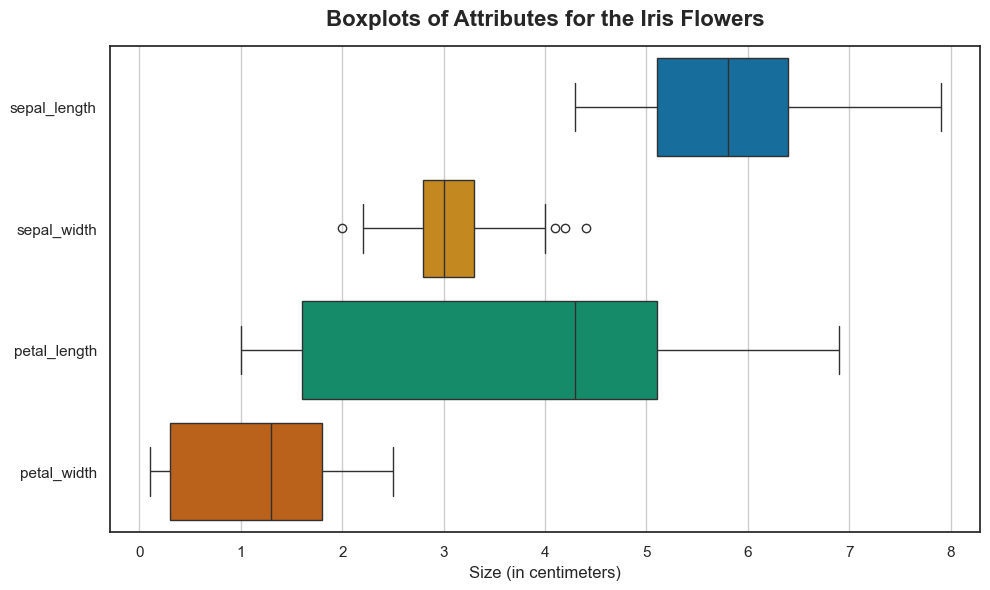

In [60]:
# Visualize the boxplots of numerical independent variables sharing the same units
plt.figure(figsize=(10, 6))
sns.boxplot(data=iris_eda[numerical_cols], orient="h")
plt.title("Boxplots of Attributes for the Iris Flowers", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Size (in centimeters)")
plt.grid(axis="x")
plt.show()

* 📌 The boxplots identified **4 potential outliers** in `sepal_width`, which appear to be natural variations rather than data entry errors.

#### 5.2.2. Categorical Features
Now let's take a look at the descriptive statistics for our categorical feature, `class_name`.

In [61]:
iris_eda['class_name'].value_counts()

class_name
setosa        50
versicolor    50
virginica     49
Name: count, dtype: int64

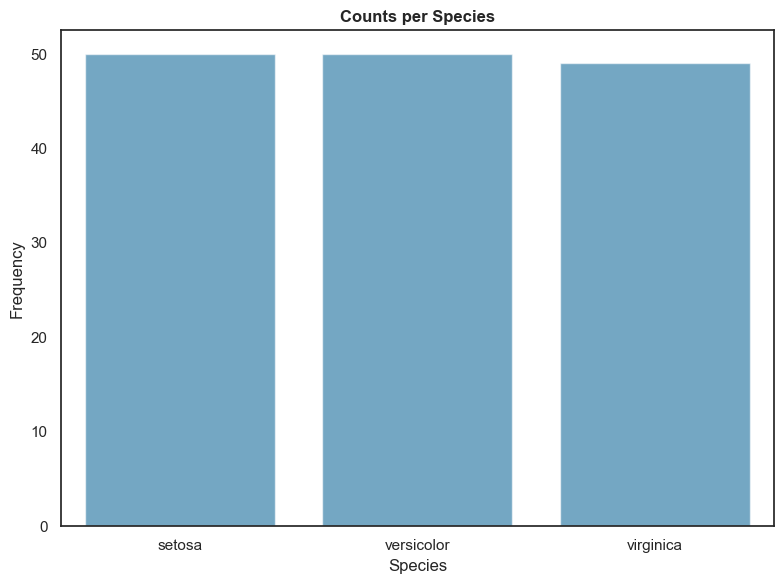

In [67]:
# Visualize the categorical column
plt.figure(figsize=(8, 6))
sns.countplot(iris_eda, x="class_name", alpha=0.6)
plt.title("Counts per Species", fontweight="bold")
plt.xlabel("Species")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

* 📌 The value counts table and count plot show that the dataset is almost perfectly balanced across the three species.

### 5.3. Univariate Analysis
Now it's time to analyze individual variables to understand their own distributions and characteristics.

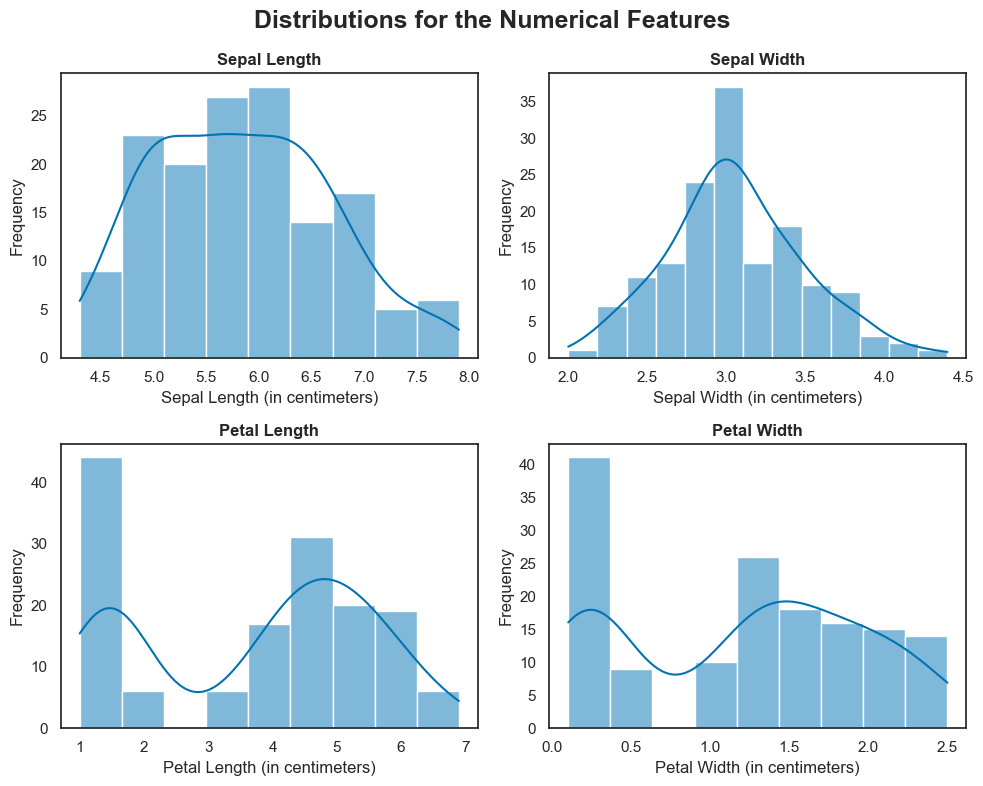

In [63]:
fig, axs = plt.subplots(2,2, figsize=(10, 8))
fig.suptitle("Distributions for the Numerical Features", fontweight="bold", fontsize=18)

sns.histplot(iris_df, x="sepal_length", ax=axs[0, 0], kde=True)
axs[0, 0].set_title("Sepal Length", fontweight="bold")
axs[0, 0].set_xlabel("Sepal Length (in centimeters)")
axs[0, 0].set_ylabel("Frequency")

sns.histplot(iris_df, x="sepal_width", ax=axs[0, 1], kde=True)
axs[0, 1].set_title("Sepal Width", fontweight="bold")
axs[0, 1].set_xlabel("Sepal Width (in centimeters)")
axs[0, 1].set_ylabel("Frequency")

sns.histplot(iris_df, x="petal_length", ax=axs[1, 0], kde=True)
axs[1, 0].set_title("Petal Length", fontweight="bold")
axs[1, 0].set_xlabel("Petal Length (in centimeters)")
axs[1, 0].set_ylabel("Frequency")

sns.histplot(iris_df, x="petal_width", ax=axs[1, 1], kde=True)
axs[1, 1].set_title("Petal Width", fontweight="bold")
axs[1, 1].set_xlabel("Petal Width (in centimeters)")
axs[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

* 📌 `sepal_length` and `sepal_width` show roughly normal, unimodal (single-peaked) distributions.
* 📌 In contrast, `petal_length` and `petal_width` are strongly bimodal (double-peaked). This bimodal nature is a powerful signal, suggesting that these two features alone can create a very effective separation between at least two distinct groups of flowers, which will likely be very useful for our classification model.

### 5.4. Bivariate Analysis
Now let's analyze pairs of variables to investigate relationships and correlations. We'll start with the pair plot, and then use a correlation matrix to further investigate any multicollinearities.



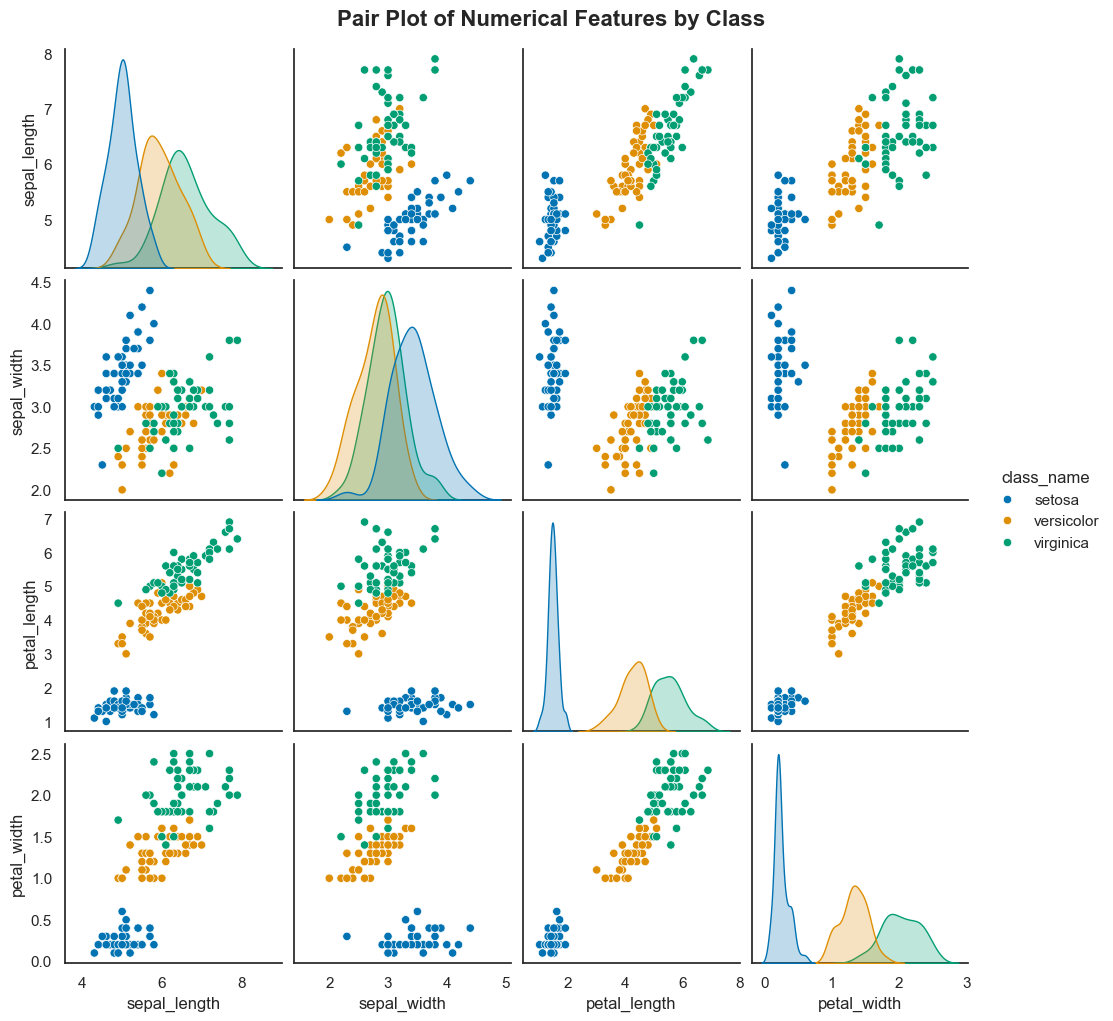

In [64]:
# Create a list of columns to use for the bivariate analysis
bivariate_cols = numerical_cols.copy()
bivariate_cols.append('class_name')

# Display the Pair Plot
pairplot = sns.pairplot(iris_eda[bivariate_cols], hue="class_name")
pairplot.figure.suptitle("Pair Plot of Numerical Features by Class", fontsize=16, fontweight="bold", y=1.02)
plt.show()

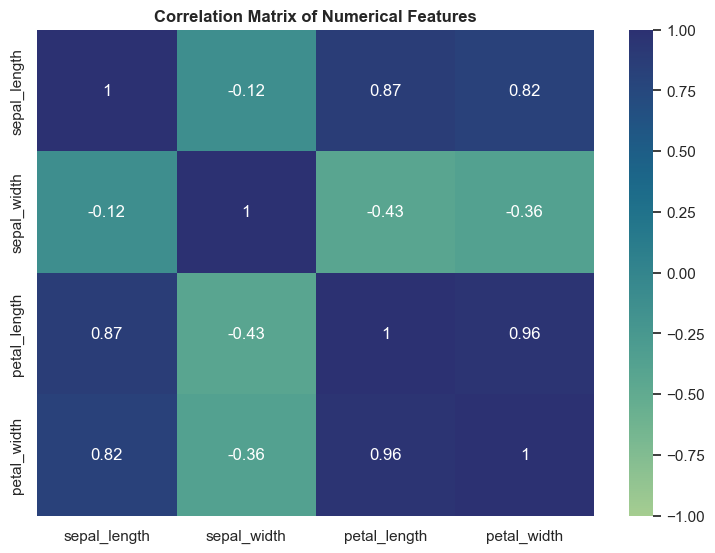

In [73]:
# Visualize the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(iris_eda[numerical_cols].corr(), cmap='crest', annot=True, vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numerical Features", fontweight="bold")
plt.show()

* 📌 Bivariate analysis strongly confirms the predictive power of petal measurements. The pair plot shows that `petal_length` and `petal_width` create a near-perfect linear separation between the classes.
* 📌 The correlation heatmap reveals a very strong positive correlation (0.96) between `petal_length` and `petal_width`, indicating significant **multicollinearity**. While this is a concern for interpreting coefficients in some linear models, it does not d typically degrade the predictive accuracy of a multi-class classification model. The analysis confirms that these petal features are the most promising predictors for our model.

---

### 📝 5. Data Understanding Report (Summary)
>
> #### 🔍 Key Insights
>
> *   **Petal Dimensions are Powerfully Predictive:** The most significant finding from the EDA is that `petal_length` and `petal_width` are extremely strong predictors of the flower species. Their bimodal distributions and clear linear separability in the pair plots indicate they will be the most valuable features for the classification model.
> *   **Dataset is Well-Balanced:** The three target classes (`setosa`, `versicolor`, `virginica`) are almost perfectly balanced (50, 50, and 49 samples, respectively). This is a significant advantage, as it means we will not need to implement complex techniques to handle class imbalance during modeling.
>
> #### ⚠️ Data Quality Issues
>
> *   **Outliers Investigated:** Four potential outliers were identified in the `sepal_width` feature via boxplots. After visual inspection, these were deemed to be natural variations within the dataset and not data entry errors. They have been retained for the modeling stage.
> *   **Multicollinearity Noted:** A very high positive correlation (0.96) exists between `petal_length` and `petal_width`. While this multicollinearity would be a concern for an inferential linear model, it is not expected to negatively impact the predictive performance of the classification models we plan to use.

---